<a href="https://colab.research.google.com/github/AnhNgoc201/Deeplearning/blob/main/Thuchanh_Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Xử lí dữ liệu và train model

## Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Đọc dữ liệu

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/23_HOMES.csv")

## Làm sạch dữ liệu

### Xem tổng dữ liệu

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes          40 non-null     int64  
 6   Rooms          40 non-null     int64  
 7   Bedrooms       40 non-null     int64  
 8   Baths_full     40 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 2.9 KB


,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,342672.500000,349937.500000,2058.375000,1.690250,38.125000,4626.625000,7.675000,3.300000,1.900000
std,83236.659784,84592.348831,657.934674,2.007324,22.944959,1848.538947,1.654636,0.723241,0.744208
min,210000.000000,219900.000000,1066.000000,0.250000,6.000000,1367.000000,4.000000,2.000000,1.000000
25%,292000.000000,294975.000000,1646.250000,0.667500,24.750000,3479.750000,6.000000,3.000000,1.000000
50%,309000.000000,319900.000000,1855.000000,1.000000,35.500000,4129.500000,8.000000,3.000000,2.000000
75%,388750.000000,395925.000000,2412.000000,1.880000,46.250000,5530.250000,9.000000,4.000000,2.000000
max,520000.000000,529700.000000,3867.000000,11.580000,144.000000,9809.000000,11.000000,5.000000,4.000000


### Kiểm tra dữ liệu

#### Kiểm tra missing values

In [ ]:
print("Missing values:\n", df.isnull().sum())
if df.isnull().sum().sum() > 0:
    print("Có missing values → đang xử lý...")
    df.fillna(df.mean(numeric_only=True), inplace=True)
else:
    print("Không có missing values")

Missing values:
 Selling_Price    0
List_Price       0
Area             0
Acres            0
Age              0
Taxes            0
Rooms            0
Bedrooms         0
Baths_full       0
dtype: int64
Không có missing values


#### Kiểm tra duplicate

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    print("Có dữ liệu trùng → đang xóa...")
    df.drop_duplicates(inplace=True)
else:
    print("Không có duplicate")

Duplicate rows: 0
Không có duplicate


####Kiểm tra kiểu dữ liệu

In [ ]:
print("\nData types:\n", df.dtypes)
if any(df.dtypes == 'object'):
    print("Có cột dạng object → đang chuyển...")
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
else:
    print("Tất cả đều là số")


Data types:
 Selling_Price      int64
List_Price         int64
Area               int64
Acres            float64
Age                int64
Taxes              int64
Rooms              int64
Bedrooms           int64
Baths_full         int64
dtype: object
Tất cả đều là số


## Chuẩn bị X, Y

Các biến đầu vào

In [ ]:
X = df.drop("Selling_Price", axis=1)

Biến mục tiêu (target)

In [ ]:
y = df["Selling_Price"]

## Chuẩn hóa dữ liệu

In [ ]:
from sklearn.preprocessing import StandardScaler

# X
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# y
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

## Chia tập dữ liệu

Chia dữ liệu thành 2 tập train và test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled,
    test_size=0.2,
    random_state=42
)

##Huấn luyện theo Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
y_pred_lr = lr.predict(X_test)

y_pred_lr_real = scaler_y.inverse_transform(y_pred_lr)
y_test_real = scaler_y.inverse_transform(y_test)

print("Dự đoán:", y_pred_lr_real[:5])
print("Thực tế:", y_test_real[:5])

Dự đoán: [[306425.90005949]
 [273157.89666297]
 [277445.7839424 ]
 [353200.07308765]
 [272766.87227333]]
Thực tế: [[300000.]
 [292000.]
 [280000.]
 [355500.]
 [265000.]]


##Huấn luyện theo ANN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

ann = Sequential()
ann.add(Input(shape=(X_train.shape[1],)))
ann.add(Dense(16, activation='relu'))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1))

ann.compile(optimizer='adam', loss='mse')

history = ann.fit(X_train, y_train, epochs=50, verbose=0)

In [ ]:
y_pred_ann = ann.predict(X_test, verbose=0)

y_pred_ann_real = scaler_y.inverse_transform(y_pred_ann)

print("Dự đoán:", y_pred_ann_real[:5])
print("Thực tế:", y_test_real[:5])

Dự đoán: [[326091.25]
 [298536.6 ]
 [262858.9 ]
 [358674.34]
 [291752.22]]
Thực tế: [[300000.]
 [292000.]
 [280000.]
 [355500.]
 [265000.]]


##So sánh 2 model

Model nào có MSE thấp hơn thì model đó tốt hơn

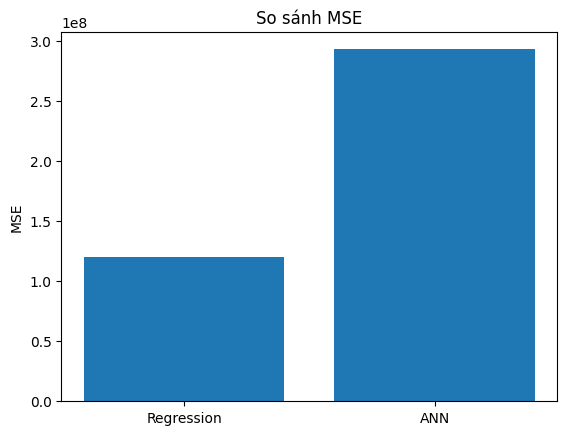

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Regression
mse_lr = mean_squared_error(y_test_real, y_pred_lr_real)

# ANN
mse_ann = mean_squared_error(y_test_real, y_pred_ann_real)

models = ['Regression', 'ANN']
errors = [mse_lr, mse_ann]

plt.bar(models, errors)
plt.title("So sánh MSE")
plt.ylabel("MSE")
plt.show()